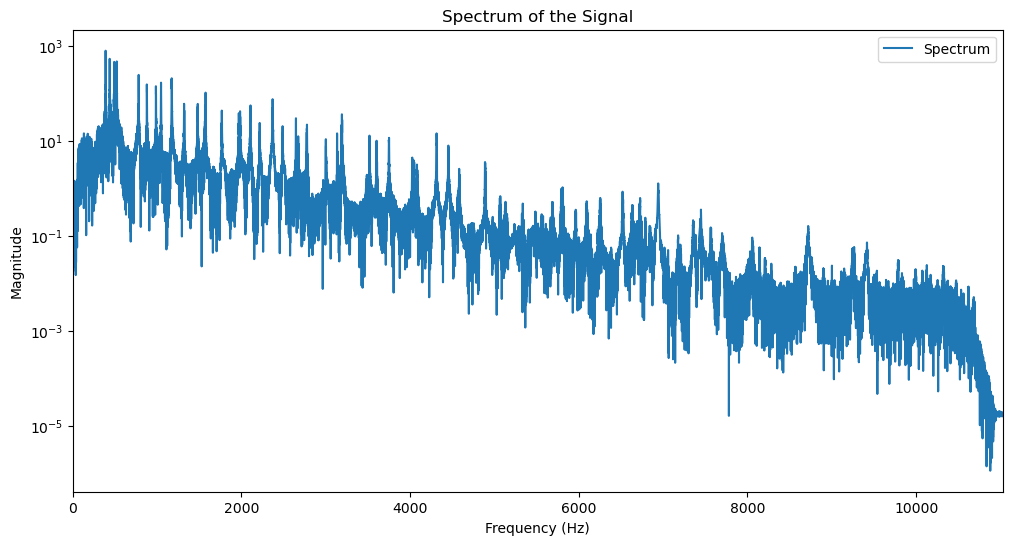

In [35]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

signal, sr = librosa.load("C:\\Users\\gmdid\\Downloads\\sound.wav", sr=22050, mono=True)

frame_len = 2048
hop_len = 512
min_freq = 20
max_freq = 1000

min_tau = int(sr / max_freq)
max_tau = int(sr / min_freq)

frames = librosa.util.frame(signal, frame_length=frame_len, hop_length=hop_len).T

Y=np.fft.rfft(signal)
freqs = np.fft.rfftfreq(len(signal), 1/sr)
magnitude = np.abs(Y)
plt.figure(figsize=(12,6))
plt.semilogy(freqs, magnitude, label = 'Spectrum')
plt.xlim(0,sr/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Spectrum of the Signal')
plt.legend()
plt.show()



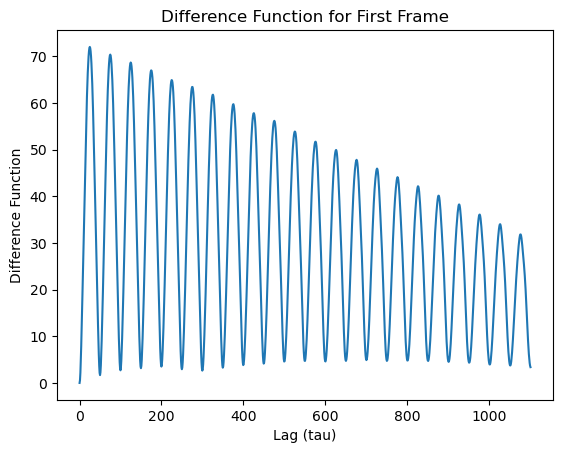

In [36]:
import matplotlib.pyplot as plt
def difference_func(frame, max_tau):
    N = len(frame)
    d = np.zeros(max_tau + 1)
    for tau in range(1, max_tau + 1):
        diff = frame[:N-tau] - frame[tau:]
        d[tau] = np.sum(diff**2)
    return d

plt.plot(difference_func(frames[0], max_tau))
plt.xlabel("Lag (tau)")
plt.ylabel("Difference Function")
plt.title("Difference Function for First Frame")
plt.show()


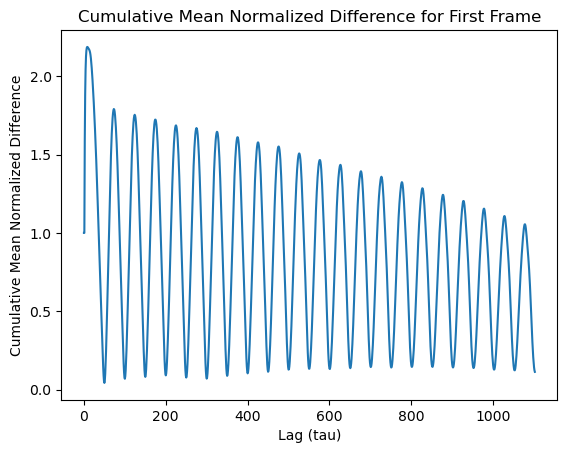

In [37]:
def cumulative_mean_normalized_difference(d):
    cmnd = np.zeros_like(d)
    cmnd[1:] = d[1:] * np.arange(1, len(d)) / np.cumsum(d[1:])
    cmnd[0] = 1.0
    return cmnd

cmnd = cumulative_mean_normalized_difference(difference_func(frames[0], max_tau))
plt.plot(cmnd)
plt.xlabel("Lag (tau)")
plt.ylabel("Cumulative Mean Normalized Difference")
plt.title("Cumulative Mean Normalized Difference for First Frame")
plt.show()

In [38]:
def get_pitch_tau(cmnd, threshold):
    for tau in range(1, len(cmnd)-1):
        if cmnd[tau] < threshold:
            if cmnd[tau] <= cmnd[tau+1]:
                return tau
    return None
get_pitch_tau(cmnd, 0.1)

50

In [39]:
def parabolic_interpolation(cmnd, tau):
    alpha = cmnd[tau-1]
    beta = cmnd[tau]
    gamma = cmnd[tau+1]
    denom = alpha-2*beta + gamma
    if denom ==0:
        return tau
    return tau + 0.5 * (alpha - gamma)/denom

tau = get_pitch_tau(cmnd, 0.1)
print(type(tau))


if tau is not None:
    refined_tau = parabolic_interpolation(cmnd, tau)
    pitch = sr / refined_tau
    print(f"Estimated pitch: {pitch:.2f} Hz")
else:
    pitch_hz = np.nan
    print("No pitch detected")
    

<class 'int'>
Estimated pitch: 441.85 Hz


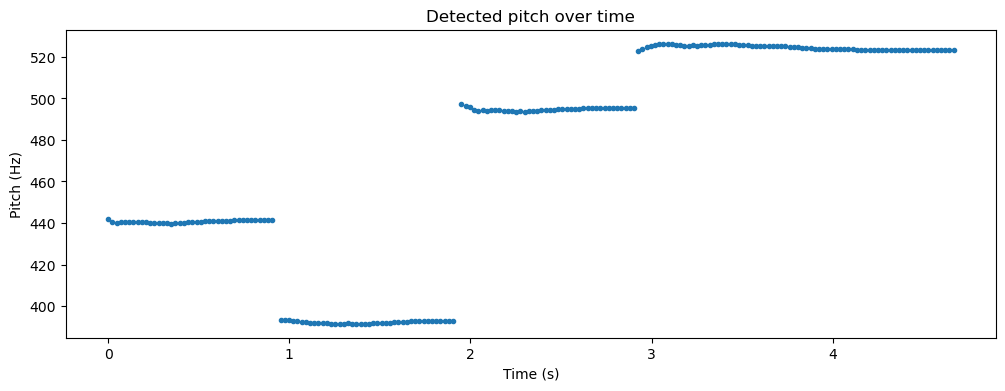

Estimated pitch at .8 seconds: 441.49 Hz
Estimated pitch at 1.5 seconds: 391.76 Hz
Estimated pitch at 2.5 seconds: 494.78 Hz
Estimated pitch at 3.5 seconds: 525.92 Hz


In [42]:
def yin_pitch(frame, sr, max_tau, threshold=0.1):
      d = difference_func(frame, max_tau)
      c = cumulative_mean_normalized_difference(d)
      tau = get_pitch_tau(c, threshold)
      if tau is None:
          return np.nan
      return sr / parabolic_interpolation(c, tau)

times   = librosa.frames_to_time(np.arange(len(frames)), sr=sr, hop_length=hop_len)
pitches = np.array([yin_pitch(f, sr, max_tau) for f in frames])

plt.figure(figsize=(12, 4))
plt.plot(times, pitches, '.')
plt.xlabel("Time (s)"); plt.ylabel("Pitch (Hz)")
plt.title("Detected pitch over time")
plt.show()

print(f"Estimated pitch at .8 seconds: {yin_pitch(frames[int(0.8*sr/hop_len)], sr, max_tau):.2f} Hz")
print(f"Estimated pitch at 1.5 seconds: {yin_pitch(frames[int(1.5*sr/hop_len)], sr, max_tau):.2f} Hz")
print(f"Estimated pitch at 2.5 seconds: {yin_pitch(frames[int(2.5*sr/hop_len)], sr, max_tau):.2f} Hz")
print(f"Estimated pitch at 3.5 seconds: {yin_pitch(frames[int(3.5*sr/hop_len)], sr, max_tau):.2f} Hz")